In [534]:
import numpy as np
import math
import pandas as pd
import plotly.express as px
import matplotlib as plt


In [535]:
A = np.array([1,-1.5])
B = np.array([2,2])
C = np.array([3,3])
np.random.seed(41)
k =3 

In [536]:
a = [A[0]+np.random.randn(50),A[1]+np.random.randn(50)]
b = [B[0]+np.random.randn(50),B[1]+np.random.randn(50)]
c = [C[0]+np.random.randn(50),C[1]+np.random.randn(50)]

In [537]:
data = np.transpose( np.concatenate((a,b,c),axis=1) )

In [538]:
print(np.shape(data))
df = pd.DataFrame(data,columns=["x","y"])


(150, 2)


In [539]:
fig =px.scatter(df,x="x",y="y")

In [540]:
fig.show()

In [541]:
ridx = np.random.choice(range(len(data)),k,replace=False)



In [542]:
print(ridx)

[111 113 147]


In [543]:
centroids = data[ridx,:]

In [544]:
print(centroids)

[[2.21189404 3.20325067]
 [2.71386771 3.52440461]
 [4.20527815 3.07114143]]


In [545]:
dists = np.zeros((data.shape[0],k))


In [ ]:
num_iterations = 30
for i in range(num_iterations):
    old_centroids = centroids.copy()
    for ci in range(k):
        dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)

    labels = np.argmin(dists,axis=1)

    for ki in range(k):
        centroids[ki,:] = np.mean(data[labels==ki],axis=0) 
    if np.allclose(old_centroids, centroids):
        print(f"Converged! The centroids didn't get refined at iteration {i}.")
        break # Stops the loop early since nothing is changing   
    
    

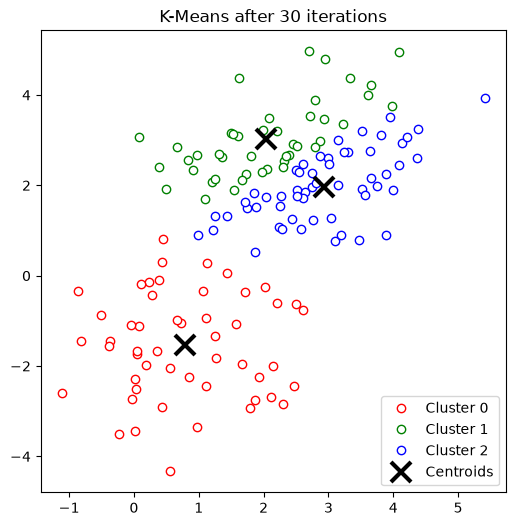

In [547]:
colors = ['r', 'g', 'b']
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))

# Plot each data point with the color of its assigned group
for ki in range(k):
    # Select only the points assigned to group ki
    plt.plot(data[labels == ki, 0], data[labels == ki, 1], colors[ki] + 'o', markerfacecolor='w', label=f'Cluster {ki}')
    
# Plot the final centroids on top as large black X's
plt.plot(centroids[:, 0], centroids[:, 1], 'kx', markersize=15, markeredgewidth=3, label='Centroids')

plt.title(f'K-Means after {num_iterations} iterations')
plt.legend()
plt.show()


In [548]:
print(centroids)

[[ 0.78969052 -1.54349874]
 [ 2.04316452  3.03220838]
 [ 2.93308936  1.97305282]]
